# Best Practices und Performance


## Übungsblatt


In [1]:
import numpy as np

### Aufgabe 1: Best Practices


Im GitHub Repository des Kurses findest du die Datei [`09_BestPracticesPerformance/ngds.py`](https://github.zhaw.ch/ADLS-Data-Science-and-Computation/Numerische-Grundlagen-FS24/blob/main/09_BestPracticesPerformance/ngds.py), in der ich am Freitag im Unterricht damit begonnen habe, ein Modul mit allen selbst-implementierten numerischecn Methoden zu erstellen. Bisher sind nur die lineare Interpolation und das Bisektionsverfahren hinzugefügt.

Deine Aufgabe ist es, das Modul zu vervollständigen, indem du alle von uns im Unterricht besprochenen Implementiereungen von numerischen Methoden hinzufügst und sauber nach den Best Practices dokumentierst und mit Assertions sicherstellt, dass die Eingabeparameter den Erwartungen entsprechen.


### Aufgabe 2: Zeitmessung mit `timeit`


Vergleiche die Laufzeit der Berechnung von

$$ y = 2x^2 -5x +2 $$

für $x \in \left\{0, 1, 2, \ldots, n-1\right\}$ zwischen einer Implementierung mit einer Schleife (List Comprehension) und mit NumPy. Ab welchem Wert von $n$ ist NumPy schneller?


In [2]:
def list_comprehension(n):
    return [2 * x**2 - 5 * x + 2 for x in range(n)]

def numpy_array(n):
    x = np.arange(n)
    return 2 * x**2 - 5 * x + 2

n = 10
%timeit list_comprehension(n)
%timeit numpy_array(n)

283 ns ± 2.71 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
2.08 μs ± 452 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [3]:
n = 50
%timeit list_comprehension(n)
%timeit numpy_array(n)

1.55 μs ± 15 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.54 μs ± 12.3 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [4]:
n = 100
%timeit list_comprehension(n)
%timeit numpy_array(n)

3.37 μs ± 39.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
1.6 μs ± 10 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


**Beobachtungen:**

- Für ca. $n < 50$ ist die List Comprehension schneller.
- Für ca. $n > 50$ ist NumPy schneller.


### Aufgabe 3: Performance Profiling mit `cProfile` bzw. `snakeviz`


In der untenstehenden Zelle ist eine einfache Lösung des [Problem des Handlungsreisenden](https://de.wikipedia.org/wiki/Problem_des_Handlungsreisenden) (_engl. Traveling Salesperson Problem_) implementiert. Dabei wird der kürzeste Weg durch eine Liste von Städten mit x-y-Koordinaten bestimmt.

Das Beispiel ist adaptiert von _Exercise 3_ von [diesem Tutorial der University of Sheffield](https://rse.shef.ac.uk/pando-python/instructor/profiling-functions.html), wo es auch eine ausführliche Erklärung von cProfile und SnakeViz gibt.

**a)** Führe den Code unten für 5 und 8 Städte aus und betrachte die Visualisierung und den Code, um zu verstehen, was eigentlich berechnet wurde. Du kannst die Anzahl Städte auch weiter erhöhen, doch Vorsicht, bei 12 Städten dauerte es bei mir bereits **fast 100 Minuten**.


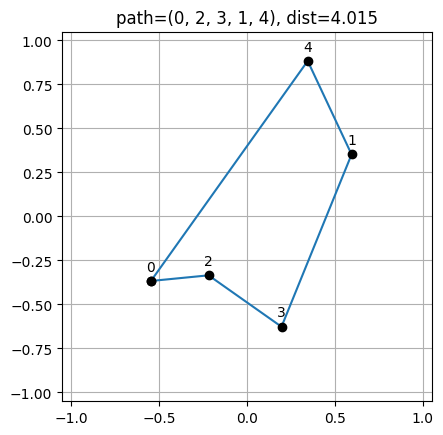

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations


def distance(city1, city2):
    """Compute the Euclidean distance between two cities."""
    return np.sqrt((city2[0] - city1[0]) ** 2 + (city2[1] - city1[1]) ** 2)


def total_distance(cities, sequence):
    """Compute the total distance to visit all the cities in the given sequence."""
    total = 0
    for i in range(len(sequence) - 1):
        total += distance(cities[sequence[i]], cities[sequence[i + 1]])
    return total + distance(cities[sequence[-1]], cities[sequence[0]])


def traveling_salesman_brute_force(cities):
    """Find the shortest path to visit all the cities exactly once by brute force."""
    min_distance = np.inf
    min_sequence = None
    for sequence in permutations(range(len(cities))):
        d = total_distance(cities, sequence)
        if d < min_distance:
            min_distance = d
            min_sequence = sequence
    return min_sequence, min_distance


def generate_cities(n, seed=12345):
    """Generate n random city coordinates."""
    rng = np.random.default_rng(seed)
    cities = []
    for _ in range(n):
        cities.append((rng.uniform(-1, 1), rng.uniform(-1, 1)))
    return cities


def plot_path(cities, sequence, min_distance):
    """Plot the path that visits the cities in the given sequence."""
    nodes = [cities[i] for i in sequence]
    nodes.append(nodes[0])
    x, y = np.array(nodes).T
    plt.plot(x, y)
    plt.plot(x, y, "ko")
    for i, city in enumerate(cities):
        plt.annotate(
            str(i),
            city,
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            va="bottom",
            annotation_clip=False,
        )
    plt.axis("square")
    plt.xlim(-1.05, 1.05)
    plt.ylim(-1.05, 1.05)
    plt.grid()
    plt.title(f"path={sequence}, dist={min_distance:.3f}")
    plt.show()


n_cities = 5
cities = generate_cities(n_cities)
shortest_path, min_distance = traveling_salesman_brute_force(cities)

plot_path(cities, shortest_path, min_distance)

**b)** Führe nun mit `cProfile` und/oder `snakeviz` ein Profiling der Funktionen `generate_cities()` und `traveling_salesman_brute_force()` durch. Du kannst entweder den Code in ein eigenes Script speichern und dort mit `cProfile` arbeiten (siehe `profiling.py`) oder die `snakeviz`-Extension in Jupyter verwenden (siehe Beispiel am Ende von `09_Best_Practices_und_Performance.ipynb`).

- Identifiziere die Teile der Funktionen, die am meisten Zeit in Anspruch nehmen.
- Variiere dazu die Anzahl Städte im Bereich 3-6 und betrachte die Auswirkungen auf die Laufzeiten der beiden Funktionen.
- Notiere deine Beobachtungen.


In [6]:
%load_ext snakeviz

In [7]:
%snakeviz -t cities = generate_cities(1000)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpkb56zcvp'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpkb56zcvp


In [8]:
%%snakeviz -t

cities = generate_cities(6)
shortest_path, min_distance = traveling_salesman_brute_force(cities)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpsosfhf_7'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpsosfhf_7


In [9]:
cities = generate_cities(9)

%snakeviz -t shortest_path, min_distance = traveling_salesman_brute_force(cities)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpyz_jxon7'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpyz_jxon7


**Beobachtungen:**

- Die Laufzeit Funktion `generate_cities()` wird bei einer kleinen Anzahl Städte dominiert von der Initialisierung des Random-Number-Generators `np.random.default_rng()`. Bei einer grossen Anzahl Städte beginnt dann das Erzeugen der Zufallszahlen auch mehr Zeit zu benötigen.
- Die Funktion `generate_cities()` braucht wesentlich weniger Zeit als `traveling_salesman_brute_force()`. Je mehr Städte, desto grösser ist der Anteil der Zeit, die in `traveling_salesman_brute_force()` verbracht wird.
- Die Laufzeit der Funktion `traveling_salesman_brute_force()` wird durch `total_distance()` dominiert und diese wiederum durch die vielen Aufrufe der Funktion `distance()`.

Das heisst, eine Optimierung sollte darauf fokussieren, die Distanzen effizienter zu berechnen und wieder zu verwenden.


**c) (optional)** Versuche die Laufzeit von `generate_cities()` und `traveling_salesman_brute_force` zu verbessern, indem du das Profiling nutzt, die langsamsten Teile des Codes identifizierst und (mithilfe von NumPy) optimierst.


**Lösung:**

`traveling_salesman_brute_force()` kann auf verschiedenste Weisen optimiert werden.

Eine Möglichkeit ist, alle Anordnungen der Städte zu generieren und dann die Länge der Route mit NumPy zu berechnen, ohne explizit über die Pfade zu iterieren. Dies ist viel schneller. Allerdings könnte es bei einer grossen Anzahl Städte zu einem Speicherproblem führen, da alle Anordnungen im Speicher gehalten werden müssen.


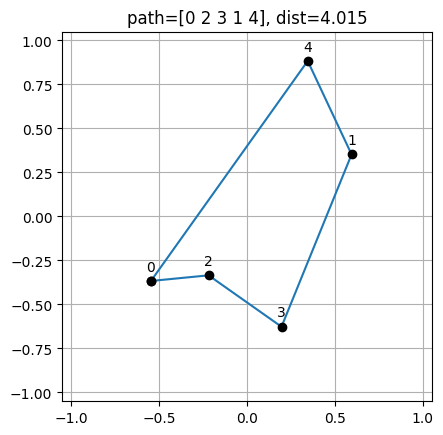

In [10]:
def traveling_salesman_brute_force_vectorized(cities):
    """Find the shortest path to visit all the cities exactly once by brute force."""
    cities = np.array(cities)
    n_cities = cities.shape[0]
    # Generate all permutations of city indices
    sequences = np.array(list(permutations(range(n_cities))))
    # Create all possible paths
    paths = cities[sequences]
    # Compute the vectors between consecutive cities
    diffs = np.diff(paths, axis=1)
    # Compute the distances between consecutive cities
    distances = np.linalg.norm(diffs, axis=2)
    # Compute the distance to return to the starting city
    return_distances = np.linalg.norm(paths[:, 0] - paths[:, -1], axis=1)
    # Compute the total lengths of each path
    lengths = np.sum(distances, axis=1) + return_distances
    # Find the minimum length and corresponding sequence
    min_index = np.argmin(lengths)
    min_length = lengths[min_index]
    min_sequence = sequences[min_index]
    return min_sequence, min_length


n_cities = 5
cities = generate_cities(n_cities)
shortest_path, min_distance = traveling_salesman_brute_force_vectorized(cities)

plot_path(cities, shortest_path, min_distance)

In [11]:
cities = generate_cities(9)

%snakeviz -t shortest_path, min_distance = traveling_salesman_brute_force_vectorized(cities)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpmja2k6q4'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpmja2k6q4
